# Chapter 29 Lab — Statistical Power and Sample Size (Python)

In this lab you will build an fMRI power calculator from first principles and use it to answer
the questions every study proposal must face: *How many participants do I need? What is the
smallest effect I can detect? And how much will the "winner's curse" inflate my post hoc effect
sizes?* We compute power analytically from the noncentral t distribution, verify it by
simulation, quantify the cost of multiple comparisons correction, and reproduce the core of the
univariate-vs-multivariate power argument from the BWAS debate (Marek et al., 2022).

**How to run this:** This notebook runs in the browser (Pyodide), on
[Colab](https://colab.research.google.com/), or locally — it uses only numpy, scipy, and
matplotlib on simulated data, and every cell runs in seconds. It accompanies the
[Chapter 29 tutorial page](../ch29-statistical-power-and-sample-size.md).

*Calculations mirror the CANlab power utilities and simulation scripts behind the book's
figures (github.com/canlab).*

**▶ This notebook is interactive.** Click the **⏻ power icon** at the top right of this page to run it in your browser — no installation needed (the kernel takes ~30–60 s to start the first time). Then run cells **top to bottom**, starting with the first code cell below: later cells depend on the imports and variables defined earlier, and will error if you skip ahead.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

rng = np.random.default_rng(29)
plt.rcParams["figure.dpi"] = 90

## Step 1 — Power for a one-sample t-test, analytically

For a one-sample t-test with true effect size $d = \mu/\sigma$ and sample size $N$, the test
statistic follows a **noncentral t distribution** with $N-1$ degrees of freedom and
noncentrality parameter $\delta = d\sqrt{N}$. Power is the probability that this statistic
exceeds the critical value:

$$
\text{power} = 1 - F_{nct}\!\left(t_{crit};\; N-1,\; d\sqrt{N}\right)
$$

For a two-sample (balanced) comparison, $\delta = d\sqrt{n/2}$ with $n$ per group and
$df = 2n - 2$ — which is why group comparisons need roughly **4× the total sample**.
For correlations we use the Fisher z approximation: $\text{atanh}(r)$ is approximately normal
with standard error $1/\sqrt{N-3}$.

One convention to fix up front: a *planned* test is usually two-tailed ($\alpha$ split between
tails), whereas thresholds applied to fMRI statistic maps ("$p < .001$") are conventionally
**directional** — one tail, because we threshold positive activations. Our functions take a
`tails` argument so we can follow that convention and reproduce the book's reference numbers.

In [2]:
def power_one_sample(d, n, alpha=0.05, tails=2):
    """Power of a one-sample t-test with true effect size d.

    tails=2 for a two-sided planned test; tails=1 for the directional
    thresholds conventionally applied to fMRI statistic maps.
    """
    n = np.asarray(n, dtype=float)
    df = n - 1
    t_crit = stats.t.ppf(1 - alpha / tails, df)
    return 1 - stats.nct.cdf(t_crit, df, d * np.sqrt(n))

def power_two_sample(d, n_per_group, alpha=0.05, tails=2):
    """Power of a two-sample t-test, balanced groups of size n_per_group."""
    n = np.asarray(n_per_group, dtype=float)
    df = 2 * n - 2
    t_crit = stats.t.ppf(1 - alpha / tails, df)
    return 1 - stats.nct.cdf(t_crit, df, d * np.sqrt(n / 2))

def power_correlation(r, n, alpha=0.05, tails=2):
    """Power to detect a correlation r, Fisher z approximation."""
    n = np.asarray(n, dtype=float)
    z_crit = stats.norm.ppf(1 - alpha / tails)
    return stats.norm.cdf(np.sqrt(n - 3) * np.arctanh(r) - z_crit)

def n_for_power(power_fn, effect, alpha=0.05, tails=2, target=0.80, n_max=6000):
    """Smallest N (or n per group) achieving the target power."""
    n = np.arange(3, n_max)
    pow_curve = power_fn(effect, n, alpha, tails)
    idx = np.argmax(pow_curve >= target)
    return int(n[idx]) if pow_curve[idx] >= target else None

# Quick check against benchmark values
for d in [0.2, 0.5, 0.8]:
    print(f"d = {d}: N = {n_for_power(power_one_sample, d):>4d} "
          f"for 80% power (one-sample, p < .05 two-tailed)")

d = 0.2: N =  199 for 80% power (one-sample, p < .05 two-tailed)
d = 0.5: N =   34 for 80% power (one-sample, p < .05 two-tailed)
d = 0.8: N =   15 for 80% power (one-sample, p < .05 two-tailed)


A "medium" effect of $d = 0.5$ needs about **N = 34** — matching standard power software
(e.g., G\*Power). Now draw the classic power curves: power as a function of $N$ for several
effect sizes.

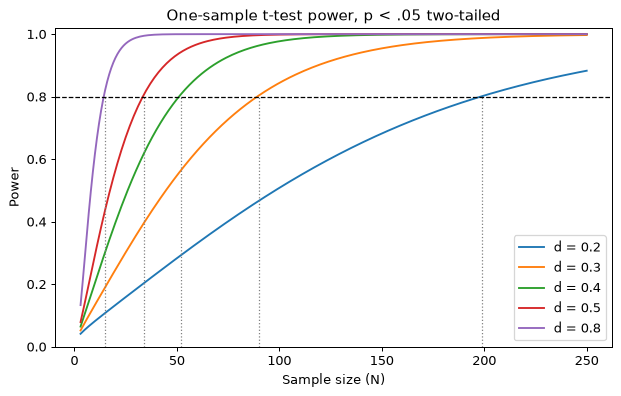

In [3]:
d_vals = [0.2, 0.3, 0.4, 0.5, 0.8]
N = np.arange(3, 251)

fig, ax = plt.subplots(figsize=(7, 4.5))
for d in d_vals:
    ax.plot(N, power_one_sample(d, N), label=f"d = {d}")
    n80 = n_for_power(power_one_sample, d)
    if n80 is not None and n80 <= N.max():
        ax.plot([n80, n80], [0, 0.8], ":", color="gray", lw=1)
ax.axhline(0.8, ls="--", color="k", lw=1)
ax.set(xlabel="Sample size (N)", ylabel="Power",
       title="One-sample t-test power, p < .05 two-tailed")
ax.legend(); ax.set_ylim(0, 1.02); plt.tight_layout()

Each curve rises toward 1 as $N$ grows, but the sample size needed for 80% power
(dotted drop lines) explodes as effects shrink: $d = 0.8$ needs ~15 participants, $d = 0.2$
needs ~199. **Sanity check by simulation** — power is just the long-run fraction of
significant results, so we can verify the analytic curve with brute force.

In [4]:
def simulated_power(d, n, alpha=0.05, n_sims=2000):
    """Fraction of simulated one-sample experiments reaching p < alpha."""
    dat = d + rng.standard_normal((n_sims, n))
    t, p = stats.ttest_1samp(dat, 0.0, axis=1)
    return np.mean(p < alpha)

print(f"{'N':>4} {'analytic':>9} {'simulated':>10}")
for n in [10, 20, 34, 50, 80]:
    print(f"{n:>4} {power_one_sample(0.5, n):>9.3f} {simulated_power(0.5, n):>10.3f}")

   N  analytic  simulated
  10     0.293      0.300
  20     0.564      0.573
  34     0.808      0.806
  50     0.934      0.936
  80     0.993      0.994


Analytic and simulated power agree to within Monte Carlo error. From here on we trust the
analytic formulas.

## Step 2 — The cost of multiple comparisons

A mass-univariate analysis cannot use $\alpha = 0.05$ per voxel. Correction pushes the
effective per-test threshold to roughly:

| Threshold | Tails | Typical use |
|---|---|---|
| $p < 0.05$ | 2 | one pre-registered ROI test |
| $p < 0.001$ | 1 | uncorrected mapping; often approximates FDR $q < .05$ |
| $p < 0.05/1000$ | 1 | Bonferroni over ~1,000 parcels/tests |
| $p < 4.26\times 10^{-6}$ | 1 | whole-brain FWER (permutation-based, empirical average) |

How does the required sample size change across these thresholds — and how much worse is a
two-group comparison?

In [5]:
thresholds = [("p < .05, two-tailed (ROI)", 0.05, 2),
              ("p < .001 (~FDR q < .05)", 0.001, 1),
              ("Bonferroni, 1,000 tests", 0.05 / 1000, 1),
              ("FWER whole brain", 4.26e-6, 1)]

d_grid = [0.2, 0.3, 0.5, 0.8]
header = f"{'threshold':<26}" + "".join(f"  d={d:<5}" for d in d_grid)

print("N for 80% power, ONE-SAMPLE test (e.g., task activation vs. baseline)")
print(header)
for name, a, t in thresholds:
    row = [n_for_power(power_one_sample, d, alpha=a, tails=t) for d in d_grid]
    print(f"{name:<26}" + "".join(f"  {n:<6}" for n in row))

print("\nTOTAL N for 80% power, TWO-GROUP comparison (patients vs. controls)")
print(header)
for name, a, t in thresholds:
    row = [2 * n_for_power(power_two_sample, d, alpha=a, tails=t) for d in d_grid]
    print(f"{name:<26}" + "".join(f"  {n:<6}" for n in row))

N for 80% power, ONE-SAMPLE test (e.g., task activation vs. baseline)
threshold                   d=0.2    d=0.3    d=0.5    d=0.8  
p < .05, two-tailed (ROI)   199     90      34      15    
p < .001 (~FDR q < .05)     392     177     67      29    
Bonferroni, 1,000 tests     568     257     98      43    
FWER whole brain            711     322     122     54    

TOTAL N for 80% power, TWO-GROUP comparison (patients vs. controls)
threshold                   d=0.2    d=0.3    d=0.5    d=0.8  
p < .05, two-tailed (ROI)   788     352     128     52    
p < .001 (~FDR q < .05)     1552    692     254     102   


Bonferroni, 1,000 tests     2248    1004    366     148   
FWER whole brain            2812    1256    460     186   


Reading down each column, correcting for multiplicity multiplies the required sample by
~3–4×: a medium effect ($d = 0.5$) needs **34** participants for one ROI test but about
**122** under whole-brain FWER correction. Reading across the two tables, the two-group
comparison needs roughly **4× the total sample** — 128 total for $d = 0.5$ at $p < .05$, and
about 460 with FWER correction. (These are the book's planning numbers: N = 34, 121, 130, and
466.) The same logic applies to brain–behavior correlations:

N for 80% power to detect a correlation:
    r    p<.05   p<.001     FWER
  0.1      783     1539     2787
  0.2      194      380      685
  0.3       85      165      296
  0.4       47       90      160
  0.5       30       55       96


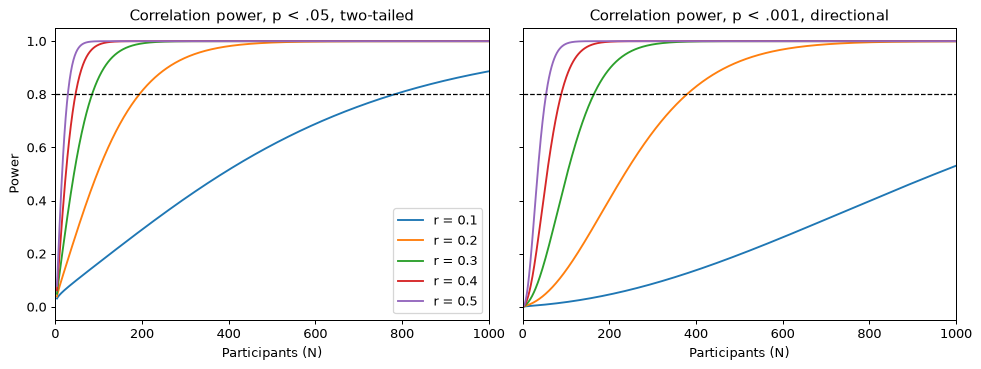

In [6]:
r_grid = [0.1, 0.2, 0.3, 0.4, 0.5]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharey=True)
N = np.arange(4, 2001)
panels = [("p < .05, two-tailed", 0.05, 2), ("p < .001, directional", 0.001, 1)]
for ax, (name, a, t) in zip(axes, panels):
    for r in r_grid:
        ax.plot(N, power_correlation(r, N, alpha=a, tails=t), label=f"r = {r}")
    ax.axhline(0.8, ls="--", color="k", lw=1)
    ax.set(xlabel="Participants (N)", title=f"Correlation power, {name}", xlim=(0, 1000))
axes[0].set_ylabel("Power"); axes[0].legend(loc="lower right")
plt.tight_layout()

print("N for 80% power to detect a correlation:")
print(f"{'r':>5} {'p<.05':>8} {'p<.001':>8} {'FWER':>8}")
for r in r_grid:
    ns = [n_for_power(power_correlation, r, alpha=a, tails=t)
          for a, t in [(0.05, 2), (0.001, 1), (4.26e-6, 1)]]
    print(f"{r:>5} " + " ".join(f"{n or '>6000':>8}" for n in ns))

These reproduce the book's Figure 29.2 reference values to within a participant or two:
detecting $r = 0.5$ needs ~28 participants for a single ROI test, ~53 at $p < .001$, and ~100
with FWER correction — while $r = 0.1$ needs roughly **780, 1,540, and 2,790**. Small
correlations and whole-brain search are a brutal combination.

## Step 3 — Minimum detectable effect size

Power analysis can be inverted: given the sample size you can afford, what is the smallest
effect you have an 80% chance of detecting? This *minimum detectable effect size* (MDES) is an
honest summary of a study's sensitivity — and a useful line for grant proposals.

In [7]:
def min_detectable_d(n, alpha, tails=2, target=0.80, d_grid=np.arange(0.05, 3.001, 0.005)):
    """Smallest one-sample d detectable with the target power at sample size n."""
    pow_curve = power_one_sample(d_grid, np.full_like(d_grid, n), alpha, tails)
    idx = np.argmax(pow_curve >= target)
    return d_grid[idx] if pow_curve[idx] >= target else np.nan

def min_detectable_r(n, alpha, tails=2, target=0.80, r_grid=np.arange(0.02, 0.9901, 0.002)):
    """Smallest correlation detectable with the target power at sample size n."""
    pow_curve = power_correlation(r_grid, np.full_like(r_grid, n), alpha, tails)
    idx = np.argmax(pow_curve >= target)
    return r_grid[idx] if pow_curve[idx] >= target else np.nan

n_grid = [30, 50, 100, 200, 500, 1000]
print("Minimum detectable effect with 80% power (one-sample d | correlation r):")
print(f"{'N':>6} {'d, p<.05':>9} {'d, FWER':>9} {'r, p<.05':>10} {'r, FWER':>9}")
for n in n_grid:
    print(f"{n:>6} {min_detectable_d(n, .05):>9.2f}"
          f" {min_detectable_d(n, 4.26e-6, tails=1):>9.2f}"
          f" {min_detectable_r(n, .05):>10.2f}"
          f" {min_detectable_r(n, 4.26e-6, tails=1):>9.2f}")

Minimum detectable effect with 80% power (one-sample d | correlation r):
     N  d, p<.05   d, FWER   r, p<.05   r, FWER
    30      0.53      1.16       0.49      0.77
    50      0.40      0.83       0.39      0.65


   100      0.28      0.56       0.28      0.49
   200      0.20      0.38       0.20      0.36
   500      0.13      0.24       0.13      0.23
  1000      0.09      0.17       0.09      0.17


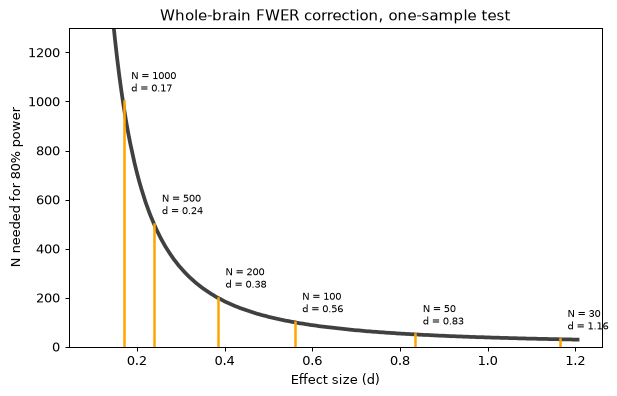

In [8]:
d_grid = np.arange(0.1, 1.21, 0.005)
n_needed = np.array([n_for_power(power_one_sample, d, alpha=4.26e-6, tails=1) or np.nan
                     for d in d_grid])

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(d_grid, n_needed, color="0.25", lw=3)
for n in [30, 50, 100, 200, 500, 1000]:
    mdes = min_detectable_d(n, 4.26e-6, tails=1)
    ax.plot([mdes, mdes], [0, n], color="orange", lw=2)
    ax.annotate(f"N = {n}\nd = {mdes:.2f}", (mdes, n), textcoords="offset points",
                xytext=(6, 8), fontsize=8)
ax.set(xlabel="Effect size (d)", ylabel="N needed for 80% power",
       title="Whole-brain FWER correction, one-sample test", ylim=(0, 1300))
plt.tight_layout()

This panel is a from-scratch reconstruction of Figure 29.2C, and the drop-lines recover its
annotations ($N = 30 \rightarrow d \approx 1.17$, $N = 100 \rightarrow d \approx 0.56$,
$N = 1000 \rightarrow d \approx 0.17$). The message: with whole-brain FWER correction, a typical
N = 30 study is powered only for *very large* effects — far larger than the $d \approx 0.5$
typical of task effects in individual voxels. This is the quantitative heart of the
"power failure" concern.

## Step 4 — The winner's curse: effect size inflation at a threshold

Now the other side of the coin. When we *estimate* effect sizes only in voxels that survived
thresholding, the estimates are biased upward: voxels are selected partly because their noise
favored the hypothesis. We simulate a brain-full of voxels **all sharing the same true effect**
($d = 0.5$, the true value in the book's Figure 29.1 simulation) and compare post hoc estimates
to the truth.

True effect size:                 d = 0.50
Mean estimate, ALL voxels:        d = 0.51   (unbiased)
Mean estimate, significant only:  d = 0.76   (52% inflated)
Voxels significant at p < .001:   28.5%  (analytic power: 28.3%)


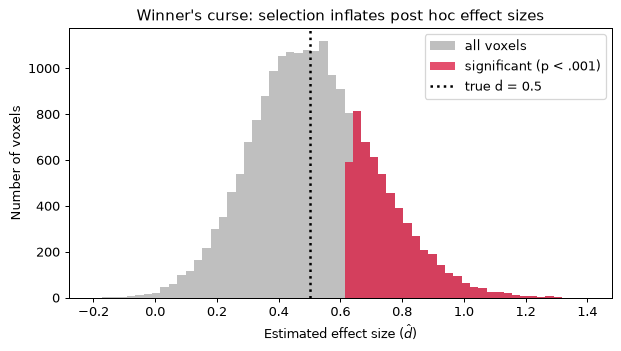

In [9]:
n_sub, n_vox, d_true = 30, 20000, 0.5

dat = d_true + rng.standard_normal((n_sub, n_vox))     # subjects x voxels
t, _ = stats.ttest_1samp(dat, 0.0)
p_dir = stats.t.sf(t, n_sub - 1)                        # directional (one-tailed) p
d_hat = t / np.sqrt(n_sub)                              # observed effect size per voxel

sig = p_dir < 0.001
print(f"True effect size:                 d = {d_true:.2f}")
print(f"Mean estimate, ALL voxels:        d = {d_hat.mean():.2f}   (unbiased)")
print(f"Mean estimate, significant only:  d = {d_hat[sig].mean():.2f}   "
      f"({100 * (d_hat[sig].mean() / d_true - 1):.0f}% inflated)")
print(f"Voxels significant at p < .001:   {sig.mean() * 100:.1f}%  "
      f"(analytic power: {100 * power_one_sample(d_true, n_sub, .001, tails=1):.1f}%)")

fig, ax = plt.subplots(figsize=(7, 4))
bins = np.linspace(-0.2, 1.4, 60)
ax.hist(d_hat, bins=bins, color="0.75", label="all voxels")
ax.hist(d_hat[sig], bins=bins, color="crimson", alpha=0.75,
        label="significant (p < .001)")
ax.axvline(d_true, color="k", ls=":", lw=2, label="true d = 0.5")
ax.set(xlabel=r"Estimated effect size ($\hat{d}$)", ylabel="Number of voxels",
       title="Winner's curse: selection inflates post hoc effect sizes")
ax.legend(); plt.tight_layout()

Every voxel has the same true effect, yet the significant subset (red) sits almost
entirely to the right of the truth. Two factors govern the inflation — threshold stringency
and sample size:

In [10]:
thresholds = [0.05, 0.005, 0.001, 4.26e-6]
sample_sizes = [15, 30, 60, 120]

print(f"{'N':>5} " + "".join(f"  p<{a:<9.2g}" for a in thresholds))
for n in sample_sizes:
    dat = d_true + rng.standard_normal((n, n_vox))
    t, _ = stats.ttest_1samp(dat, 0.0)
    p_dir = stats.t.sf(t, n - 1)                        # directional p, as in mapping
    d_hat = t / np.sqrt(n)
    row = []
    for a in thresholds:
        s = p_dir < a
        row.append(f"{d_hat[s].mean():>11.2f}" if s.sum() >= 10 else f"{'--':>11}")
    print(f"{n:>5} " + " ".join(row))
print(f"\n(True d = {d_true} everywhere. '--' = fewer than 10 significant voxels.)")

    N   p<0.05       p<0.005      p<0.001      p<4.3e-06  
   15        0.72        0.97        1.16        1.94
   30        0.57        0.67        0.76        1.09
   60        0.51        0.54        0.57        0.71
  120        0.50        0.50        0.51        0.54

(True d = 0.5 everywhere. '--' = fewer than 10 significant voxels.)


Reading across each row, stricter thresholds select luckier noise and inflate the
estimate more; reading down each column, larger samples shrink the bias (with N = 120,
significant voxels barely overestimate). **Paradoxically, correcting for multiple comparisons
makes false positives rarer but post hoc effect sizes more inflated.** This is why effect
sizes for power analysis should come from independent data — an a priori ROI, a pre-defined
pattern, or a replication sample — never from the significant voxels of the same map.

## Step 5 — The BWAS debate: univariate vs. multivariate effects

Marek, Tervo-Clemmens et al. (2022) showed that for brain-wide association studies
(correlating resting-state connectivity or structure with individual differences in behavior),
the largest *univariate* effects are around $r \approx 0.1$. Multivariate models aggregating
signal across the brain achieve up to $r \approx 0.4$ in the same data. How different are the
sample size requirements?

p < .05:  univariate r = 0.095 -> N = 868;  multivariate r = 0.39 -> N = 50  (17-fold reduction)
p < .001: univariate r = 0.10  -> N = 1539; multivariate r = 0.40 -> N = 90  (17-fold reduction)


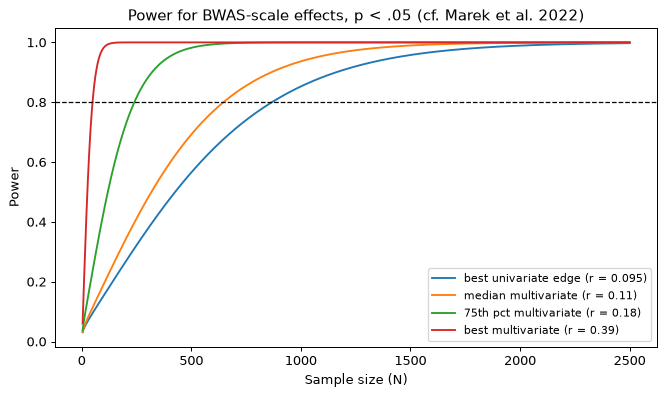

In [11]:
effects = {"best univariate edge (r = 0.095)": 0.095,
           "median multivariate (r = 0.11)": 0.11,
           "75th pct multivariate (r = 0.18)": 0.18,
           "best multivariate (r = 0.39)": 0.39}

N = np.arange(4, 2501)
fig, ax = plt.subplots(figsize=(7.5, 4.5))
for name, r in effects.items():
    ax.plot(N, power_correlation(r, N), label=name)
ax.axhline(0.8, ls="--", color="k", lw=1)
ax.set(xlabel="Sample size (N)", ylabel="Power",
       title="Power for BWAS-scale effects, p < .05 (cf. Marek et al. 2022)")
ax.legend(loc="lower right", fontsize=9); plt.tight_layout()

n_uni = n_for_power(power_correlation, 0.095)
n_multi = n_for_power(power_correlation, 0.39)
print(f"p < .05:  univariate r = 0.095 -> N = {n_uni};  "
      f"multivariate r = 0.39 -> N = {n_multi}  ({n_uni / n_multi:.0f}-fold reduction)")

# Same comparison at a p < .001 mapping threshold, using the round numbers
# quoted in the literature (univariate r = 0.1 vs. multivariate r = 0.4)
n_uni_001 = n_for_power(power_correlation, 0.10, alpha=0.001, tails=1)
n_multi_001 = n_for_power(power_correlation, 0.40, alpha=0.001, tails=1)
print(f"p < .001: univariate r = 0.10  -> N = {n_uni_001}; "
      f"multivariate r = 0.40 -> N = {n_multi_001}  "
      f"({n_uni_001 / n_multi_001:.0f}-fold reduction)")

The best univariate effects need samples in the **thousands**, while multivariate
effects of $r \approx 0.4$ are detectable with $N$ in the **tens to low hundreds** — roughly a
16–17-fold reduction (the variance-explained ratio $r^2$ is exactly 16-fold for 0.4 vs. 0.1), before any multiple comparisons correction (a multivariate model yields
*one* test, so none is needed). Task-evoked multivariate patterns can be far stronger still
($d > 3$ for some validated signatures), detectable in very small samples.

## Wrap-up

- Power depends on the **effect size** in the group analysis — the final common pathway for
  all design, acquisition, and analysis choices — and on the **effective alpha** after
  multiple comparisons correction.
- Required samples grow explosively as effects shrink: $r = 0.5$ needs ~30 participants for
  one test; $r = 0.1$ needs ~780 — and several-fold more under correction. Two-group
  comparisons need ~4× the total sample of one-sample tests.
- The **minimum detectable effect size** tells you what your planned N can honestly claim to
  test.
- Post hoc effect sizes from significant voxels are **inflated by selection** — more so with
  small samples and strict thresholds — so base power analyses on unbiased, independent
  estimates.
- Aggregating signal — a priori ROIs, networks, or **multivariate patterns** — trades
  voxel-level localization for dramatically larger effects, fewer tests, and higher power.